# Fill in the following cell with your information

 Linear Regression via Direct Optimization, Gradient Descent, and Polynomial Regression



## Part 0: Data Setup -- Run the cell below to create a dummy dataset.

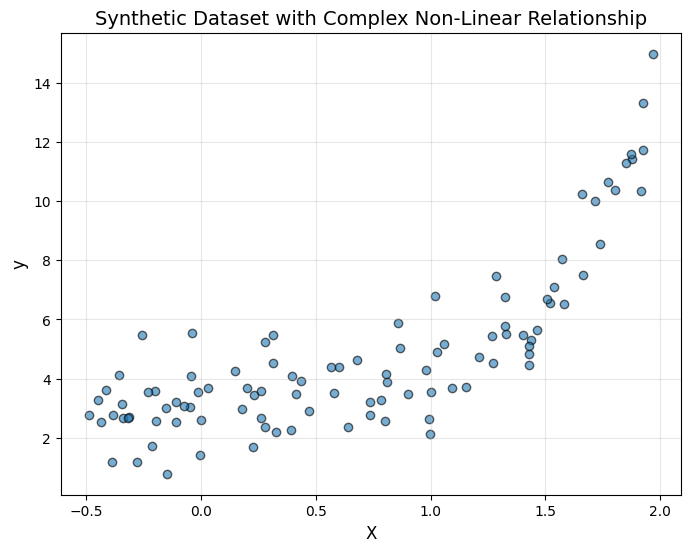

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic dataset for regression with complex non-linear relationship

i_am_using = "numpy" # Change to "pytorch" if you want to use PyTorch instead

if i_am_using == "pytorch":
    import torch
    # Generate synthetic dataset with higher-order polynomial relationship
    torch.manual_seed(42)
    N = 100 # Number of samples
    X = 2.5 * torch.rand(N, 1) - 0.5  # X in range [-0.5, 2.0]
    # Complex non-linear relationship: y = 3 + 2*X - X^3 + 0.5*X^5 + noise
    y = 3 + 2*X - X**3 + 0.5*X**5 + 1.2 * torch.randn(N, 1)

    # Add bias term (column of 1s) to X to create X_tilde
    X_tilde = torch.cat([torch.ones(N, 1), X], dim=1)

elif i_am_using == "numpy":
    np.random.seed(42)
    N = 100 # Number of samples
    X = 2.5 * np.random.rand(N, 1) - 0.5  # X in range [-0.5, 2.0]
    # Complex non-linear relationship: y = 3 + 2*X - X^3 + 0.5*X^5 + noise
    y = 3 + 2*X - X**3 + 0.5*X**5 + 1.2 * np.random.randn(N, 1)

    # Add bias term (column of 1s) to X to create X_tilde
    X_tilde = np.c_[np.ones((N, 1)), X]

# Visualize the generated data
plt.figure(figsize=(8, 6))

if i_am_using == "pytorch":
    plt.scatter(X.numpy(), y.numpy(), alpha=0.6, edgecolors='k')
elif i_am_using == "numpy":
    plt.scatter(X, y, alpha=0.6, edgecolors='k')

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Synthetic Dataset with Complex Non-Linear Relationship', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Part 1: Minimum Squared Error (MSE) Evaluation (5 pts)
To compare our models, we need a standard metric. The Mean Squared Error (MSE) represents the average squared difference between the predicted values ($\hat{y}$) and the actual ground truth values ($y$).

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Implement the MSE calculation below.

In [3]:
def calculate_mse(y_true, y_pred):
    """
    Calculates the Mean Squared Error.
    """
    mse = np.mean((y_pred - y_true)**2)
    return mse

## Part 2: Linear Regression using Least Squares (Direct Optimization) (10 pts)

Given input-output pairs $\{(x_{p},y_{p})\}_{p=1}^{P}$, we can find the optimal weights in a single mathematical step using the entire batch of data. This leads to the normal equation:

$$\tilde{w}^{*}=(\tilde{X}\tilde{X}^{\top})^{-1}\tilde{X}y$$

*(Note: Depending on matrix dimensions, this is often implemented as $\tilde{w}^{*} = (\tilde{X}^{\top}\tilde{X})^{-1}\tilde{X}^{\top}y$ in standard batch form).*

Implement the analytical solution using NumPy's or PyTorch's linear algebra functions.

In [4]:
def optimize_pseudo_inverse(X_tilde, y):
    """
    Calculates the optimal weight vector using the normal equation.
    """
    X_transpose = X_tilde.T
    optimal_weights = np.linalg.inv(X_transpose @ X_tilde) @ X_transpose @ y
    return optimal_weights

# Execute and calculate error
weights_direct = optimize_pseudo_inverse(X_tilde, y)

if i_am_using == "pytorch":
    predictions_direct = X_tilde @ weights_direct
    mse_direct = calculate_mse(y, predictions_direct)
    print(f"Direct Optimization MSE: {mse_direct.item():.6f}")
elif i_am_using == "numpy":
    predictions_direct = X_tilde.dot(weights_direct)
    mse_direct = calculate_mse(y, predictions_direct)
    print(f"Direct Optimization MSE: {mse_direct:.6f}")

Direct Optimization MSE: 3.180040


## Part 3: Iterative Optimization (Batch Gradient Descent) (25 pts)

Instead of calculating the inverse of a matrix (which can be computationally expensive), we can iteratively update our weights to minimize the MSE. 

For each epoch, calculate the gradient of the loss function with respect to the weights using the full batch, and update the weights:

$$w^{(t+1)} = w^{(t)} - \alpha \frac{2}{N} \tilde{X}^{\top} (\tilde{X}w^{(t)} - y)$$

Where $\alpha$ is the learning rate.

In [5]:
def batch_gradient_descent(X_tilde, y, learning_rate=0.1, epochs=100):
    """
    Optimizes weights using Batch Gradient Descent.
    Returns the final weights and a list of MSE values per epoch.
    """
    N = len(y)
    
    if i_am_using == "pytorch":
        weights = torch.randn(X_tilde.shape[1], 1)
    elif i_am_using == "numpy":
        weights = np.random.randn(X_tilde.shape[1], 1)
    
    mse_history = []
    
    for epoch in range(epochs):
        y_pred = X_tilde.dot(weights)
        gradient = (2/N) * X_tilde.T.dot(y_pred - y)
        weights = weights - learning_rate * gradient
        current_mse = calculate_mse(y, y_pred)
        mse_history.append(current_mse)        

    return weights, mse_history

# Execute gradient descent
weights_gd, mse_history = batch_gradient_descent(X_tilde, y, learning_rate=0.1, epochs=200)
print(f"Batch Gradient Descent Final MSE: {mse_history[-1]:.6f}")
print(f"Batch Gradient Descent Final Weights: {weights_gd.flatten()}")

Batch Gradient Descent Final MSE: 3.180040
Batch Gradient Descent Final Weights: [2.83008603 2.95923673]


## Part 4: Visualization (10 Points)

Compare the performance (e.g., convergence behavior, accuracy, fitting quality) of both Least Squares and Gradient Descent.

**Tasks:**
1. Plot the regression line for both methods on the same scatter plot of the data.
2. Plot the MSE loss curve over the epochs for the Gradient Descent method.

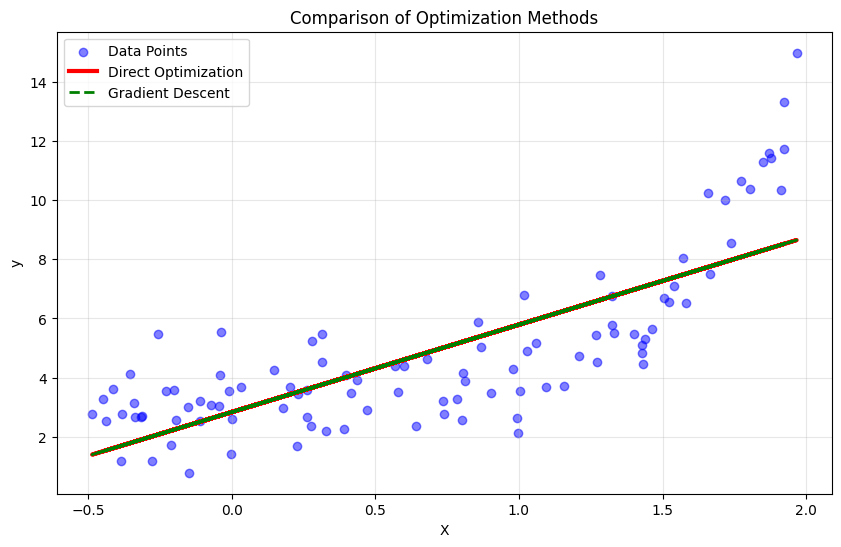

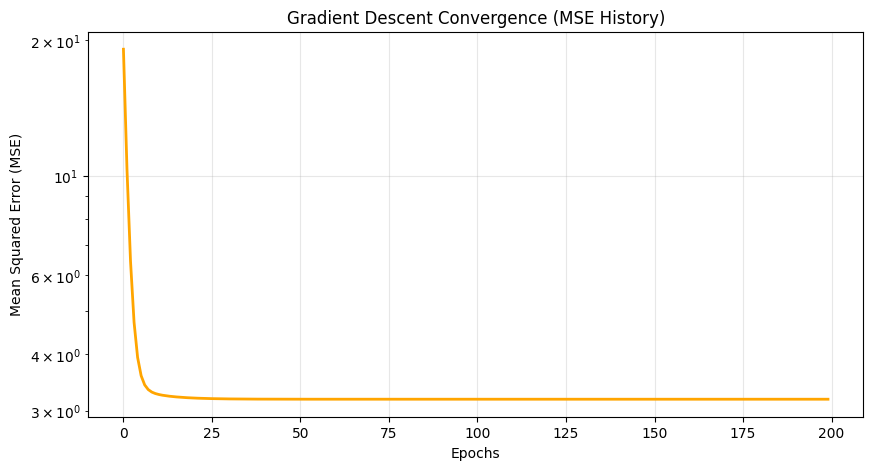

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')

if i_am_using == "numpy":
    y_pred_direct = X_tilde.dot(weights_direct)
    y_pred_gd = X_tilde.dot(weights_gd)
else:
    y_pred_direct = X_tilde @ weights_direct
    y_pred_gd = X_tilde @ weights_gd

plt.plot(X, y_pred_direct, color='red', linewidth=3, label='Direct Optimization')

plt.plot(X, y_pred_gd, color='green', linestyle='--', linewidth=2, label='Gradient Descent')

plt.title('Comparison of Optimization Methods')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(range(len(mse_history)), mse_history, color='orange', linewidth=2)

plt.title('Gradient Descent Convergence (MSE History)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.yscale('log') 
plt.show()

## Part 5: Polynomial Regression (30 pts)

So far, we have been working with linear regression, where the relationship between input and output is assumed to be linear. However, many real-world relationships are non-linear. Polynomial regression allows us to model more complex relationships by transforming our features into polynomial terms.

For a single feature $x$, a polynomial of degree $d$ creates features:
$$[1, x, x^2, x^3, ..., x^d]$$

**In this section, you will:**
1. Implement a function to create polynomial features (10 pts)
2. Train polynomial regression models of different degrees (10 pts)
3. Analyze and visualize the results to understand overfitting and underfitting (10 pts)

### Part 5.1: Creating Polynomial Features (10 pts)

First, we need to transform our input features into polynomial features. For example, if we have input $x$ and want degree 3 polynomial, we create: $[1, x, x^2, x^3]$

Implement the function below to generate polynomial features.

In [7]:
def create_polynomial_features(X, degree):
    """
    Creates polynomial features up to the specified degree.
    
    Args:
        X: Input features (N x 1)
        degree: Maximum polynomial degree
        
    Returns:
        X_poly: Polynomial features (N x (degree + 1))
                First column is bias (ones), then X, X^2, ..., X^degree
    """
    features = []
    for d in range(degree + 1):
        features.append(X**d)
    
    X_poly = np.column_stack(features)
    return X_poly

X_poly_test = create_polynomial_features(X, degree=3)

print(f"Original X shape: {X.shape}")
print(f"Polynomial features shape (degree=3): {X_poly_test.shape}")

if i_am_using == "pytorch":
    print(f"First sample - X value: {X[0].item():.6f}")
    print(f"First sample - Polynomial features: {X_poly_test[0].numpy()}")
elif i_am_using == "numpy":
    print(f"First sample - X value: {X[0].item():.6f}")
    print(f"First sample - Polynomial features: {X_poly_test[0]}")

Original X shape: (100, 1)
Polynomial features shape (degree=3): (100, 4)
First sample - X value: 0.436350
First sample - Polynomial features: [1.         0.4363503  0.19040158 0.08308179]


### Part 5.2: Training Polynomial Models of Different Degrees (20 pts)

Now that we can create polynomial features, let's train regression models with different polynomial degrees and compare their performance.

Train polynomial regression models for degrees 1, 2, 3, 5, and 10 using the direct optimization method (normal equation) you implemented earlier. Calculate and store the MSE for each degree.

In [9]:
# ==========================================
# YOUR CODE HERE
# Train polynomial regression models for degrees [1, 2, 3, 5, 10]
# For each degree:
#   1. Create polynomial features using your function
#   2. Train using optimize_pseudo_inverse()
#   3. Calculate predictions
#   4. Calculate MSE
# Store the results in dictionaries or lists for later visualization
# ==========================================

degrees = [1, 2, 3, 5, 10]
polynomial_models = {}

# Print MSE for each degree
for degree in degrees:
    X_poly = create_polynomial_features(X, degree)
    weights_poly = optimize_pseudo_inverse(X_poly, y)
    y_pred_poly = X_poly.dot(weights_poly)
    mse_val = calculate_mse(y, y_pred_poly)
    polynomial_models[degree] = {
        'weights': weights_poly,
        'mse': mse_val,
        'predictions': y_pred_poly
    }
    
    print(f"Degree {degree}: MSE = {mse_val:.6f}")

Degree 1: MSE = 3.180040
Degree 2: MSE = 1.603831
Degree 3: MSE = 1.143129
Degree 5: MSE = 1.096523
Degree 10: MSE = 1.065469


### Part 5.3: Visualization and Analysis

Now let's visualize the polynomial regression models to understand how polynomial degree affects model performance. The plots below will show:

1. **Training data and fitted curves** for all polynomial degrees (1, 2, 3, 5, 10) on the same graph
2. **MSE vs. Polynomial Degree** to visualize the relationship between model complexity and error

Run the cell below to generate the visualizations.

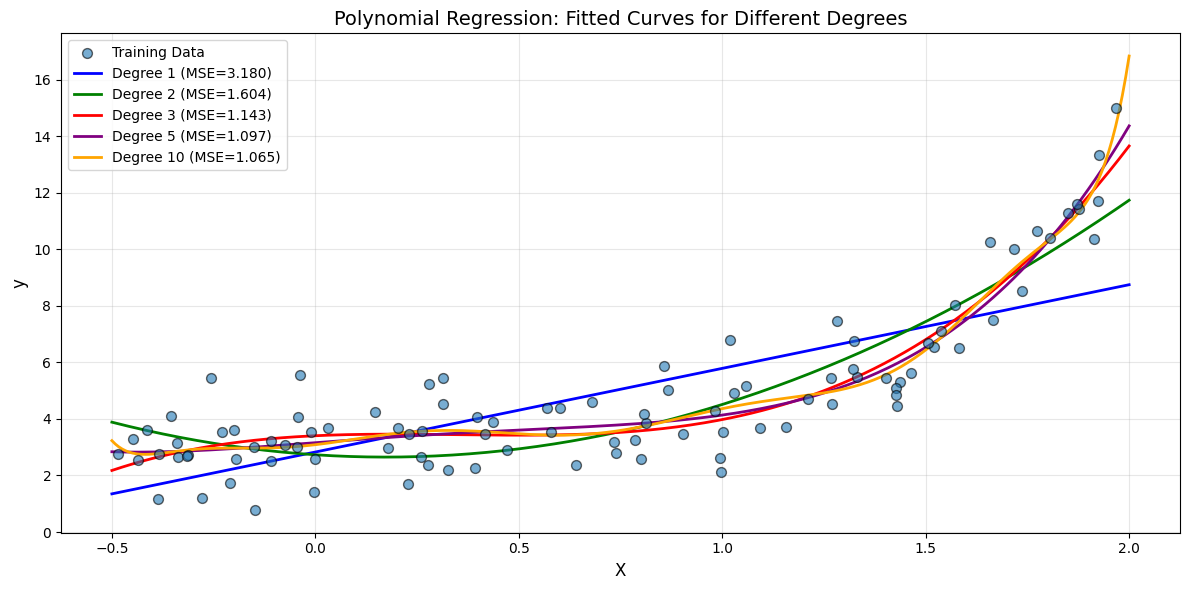

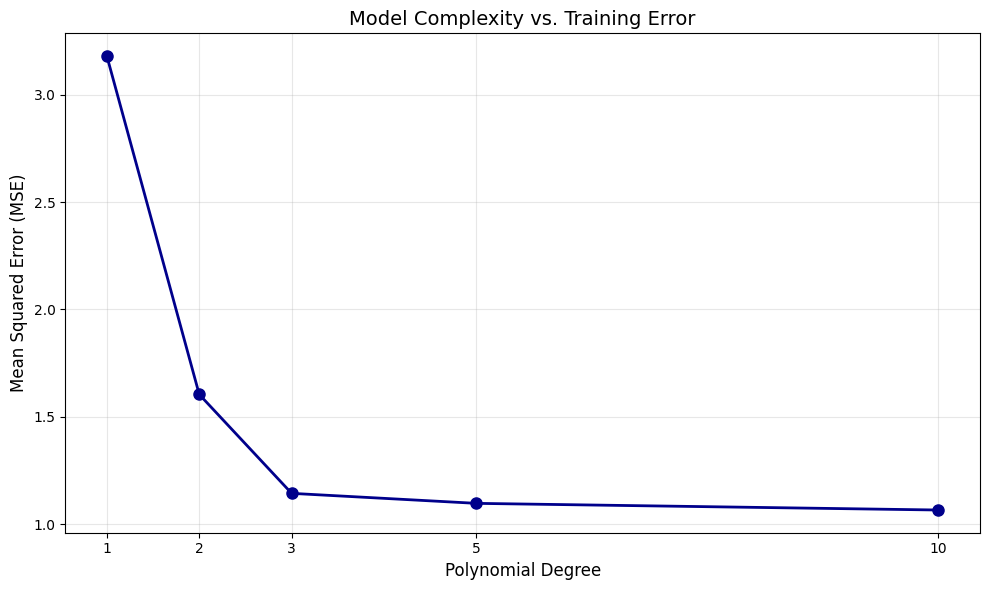

In [10]:
# Create smooth x values for plotting curves
if i_am_using == "pytorch":
    X_plot = torch.linspace(-0.5, 2.0, 300).reshape(-1, 1)
elif i_am_using == "numpy":
    X_plot = np.linspace(-0.5, 2.0, 300).reshape(-1, 1)

# Plot 1: Data and fitted curves for all polynomial degrees
plt.figure(figsize=(12, 6))

# Plot the original data points
if i_am_using == "pytorch":
    plt.scatter(X.numpy(), y.numpy(), alpha=0.6, edgecolors='k', s=50, label='Training Data', zorder=3)
elif i_am_using == "numpy":
    plt.scatter(X, y, alpha=0.6, edgecolors='k', s=50, label='Training Data', zorder=3)

# Plot fitted curves for each degree
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, degree in enumerate(degrees):
    # Create polynomial features for plotting
    X_plot_poly = create_polynomial_features(X_plot, degree)
    
    # Get predictions
    if i_am_using == "pytorch":
        y_plot = X_plot_poly @ polynomial_models[degree]['weights']
        plt.plot(X_plot.numpy(), y_plot.numpy(), color=colors[i], linewidth=2, 
                label=f'Degree {degree} (MSE={polynomial_models[degree]["mse"]:.3f})', zorder=2)
    elif i_am_using == "numpy":
        y_plot = X_plot_poly.dot(polynomial_models[degree]['weights'])
        plt.plot(X_plot, y_plot, color=colors[i], linewidth=2, 
                label=f'Degree {degree} (MSE={polynomial_models[degree]["mse"]:.3f})', zorder=2)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Polynomial Regression: Fitted Curves for Different Degrees', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: MSE vs Polynomial Degree
mse_values = [polynomial_models[degree]['mse'] for degree in degrees]

plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_values, marker='o', linewidth=2, markersize=8, color='darkblue')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Model Complexity vs. Training Error', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.tight_layout()
plt.show()

## Part 6: Discussion (20 pts)

**Q1:** How do the final weights and the final MSE compare between the Direct Optimization and Gradient Descent methods? 

**Q2:** If the dataset had 1,000,000 features, which method would you prefer and why? Consider the computational complexity of matrix inversion vs. iterative multiplication.

**Q3:** Based on your polynomial regression results, which polynomial degree provides the best fit for the synthetic data? Explain your reasoning considering both MSE and visual inspection of the curves.

**Q4:** What happens to the fitted curve as the polynomial degree increases (e.g., degree 10)? Does a lower MSE always indicate a better model? Discuss the concepts of underfitting and overfitting.

*Your Answer Below.*

Q1:
Both Direct Optimization (Least Squares) and Batch Gradient Descent try to minimize the same objective function, which is Mean Squared Error (MSE). Because of this, their final results should be almost the same.

Final Weights:
Direct Optimization finds the solution directly using the normal equation in one step. Gradient Descent, on the other hand, updates the weights step by step by moving in the direction that reduces the error. Since the MSE function in linear regression is convex (it has only one global minimum), Gradient Descent will eventually reach the same weights if the learning rate and number of epochs are chosen properly.

Final MSE:
Because the final weights are almost the same, the MSE values will also be very similar. Small differences can happen due to floating-point precision or because Gradient Descent may stop slightly before reaching the exact minimum.**Edit this cell to answer questions above.

Q2:
For a dataset with 1,000,000 features, Batch Gradient Descent is much more practical than Direct Optimization.

Direct Optimization:
This method uses the normal equation, which requires computing the inverse of the matrix X^TX. If there are 1,000,000 features, this matrix becomes 1,000,000 × 1,000,000. Matrix inversion has about O(d³) complexity, so it would require extremely large memory and computation. In practice, this is usually not feasible.

Gradient Descent:
Gradient Descent avoids matrix inversion and instead updates the weights step by step using matrix multiplications. Each iteration has roughly O(d) complexity with respect to the number of features. Even though it needs multiple iterations to converge, each step is much cheaper.

Because Direct Optimization becomes computationally infeasible with very large feature sizes, Gradient Descent is the preferred method for high-dimensional datasets.
Q3:
The best balance between model complexity and accuracy is usually at a moderate polynomial degree, such as 3 or 5. To decide the best fit, we should look at both the MSE values and the shape of the regression curve.

MSE Analysis:
As the polynomial degree increases, the MSE usually decreases. However, the biggest improvement happens when moving from degree 1 to a small polynomial degree. After that, the improvement becomes very small and the model may start fitting the noise instead of the real pattern.

Visual Inspection:
	•	Degree 1: Too simple and cannot capture the curvature → underfitting.
	•	Degree 10: The curve becomes very wavy, especially at the edges → overfitting.
	•	Degree 3 or 5: The curve follows the general trend of the data smoothly without unnecessary fluctuations.

Therefore, a moderate degree like 3 or 5 usually gives the best trade-off between fitting the data well and avoiding overfitting.
Q4:
When the polynomial degree becomes very high (like degree 10), the model becomes too flexible. The curve can pass through almost every training data point, which creates a very wavy and complex curve. However, this usually does not represent the real pattern of the data.

MSE vs Model Quality:
A lower MSE does not always mean the model is better. Sometimes it just means the model has memorized the training data, including noise and random variations, instead of learning the real relationship.

Underfitting:
If the degree is too low (for example degree 1), the model is too simple to capture the data pattern. This leads to high error on both training data and new data.

Overfitting:
If the degree is too high (like degree 10), the model becomes too complex. It fits the training data very well and gets a very low training MSE, but it usually performs poorly on new unseen data because it cannot generalize well.